In [1]:
import csv
import os
from os import path

import librosa
import numpy as np
import pandas as pd
import seaborn as sns
import torchaudio
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
DATASET_DIR = "/home/mmcneil/datasets/LibriTTS/"

def load_from_set(dir: str) -> list[dict]:
    data: list[dict] = []
    for dirpath, dirnames, filenames in os.walk(path.join(DATASET_DIR, dir)):
        for filename in filenames:
            if "normalized" in filename:
                filename_base = filename.split(".")[0]
                speaker_id = filename_base.split("_")[0]
                with open(path.join(dirpath, filename)) as infile:
                    data.append(
                        {
                            "wav": path.join(dirpath, f"{filename_base}.wav").replace(
                                DATASET_DIR, ""
                            ),
                            "speaker_id": int(speaker_id),
                            "text": infile.read(),
                        }
                    )
    return data

In [8]:
originals = set()
normalized = set()

data = (
    load_from_set("train-clean-360")
    + load_from_set("test-clean")
    + load_from_set("dev-clean")
)

df = pd.DataFrame(data)
df = df[~df["text"].str.contains(r"[\[\]—/éæê]", regex=True, na=False)]

In [9]:
df

,wav,speaker_id,text
0,train-clean-360/6895/96175/6895_96175_000017_0...,6895,With every chance she is at it.)
1,train-clean-360/6895/96175/6895_96175_000003_0...,6895,"'He knocked him over,' I replied, liking somet..."
2,train-clean-360/6895/96175/6895_96175_000032_0...,6895,She wriggled on her seat in her effort of argu...
3,train-clean-360/6895/96175/6895_96175_000044_0...,6895,"'Well, by their faces....'"
4,train-clean-360/6895/96175/6895_96175_000036_0...,6895,"I see it clearly, can't you?"
...,...,...,...
127068,dev-clean/2035/147961/2035_147961_000007_00001...,2035,Pavel called for something and struggled up on...
127069,dev-clean/2035/147961/2035_147961_000034_00000...,2035,This cabin was his hermitage until the winter ...
127070,dev-clean/2035/147961/2035_147961_000018_00000...,2035,The wolves ran like streaks of shadow; they lo...
127071,dev-clean/2035/147961/2035_147961_000024_00000...,2035,Presently the groom screamed.


In [10]:
# Because some audio clips in LibriTTS are very long in a way that complicates model training,
# we drop any wavs with a duration longer than 15 seconds. The maximum in LJSpeech is 10. 15 seconds
# approximately 95% of the dataset.
durations = []
for row in tqdm(df.itertuples(), total=len(df), desc="Determining WAV durations"):
    wav, sr = torchaudio.load(path.join(DATASET_DIR, row.wav))
    durations.append(wav.shape[-1] / sr)

df["duration"] = durations
df = df[(df.duration <= 10)&(df.duration>=1.0)].reset_index(drop=True)

Determining WAV durations: 100%|██████████| 126875/126875 [12:05<00:00, 174.79it/s]


In [11]:
df = df[(df.duration <= 10) & (df.duration >= 1)].reset_index(drop=True)

<Axes: xlabel='duration', ylabel='Count'>

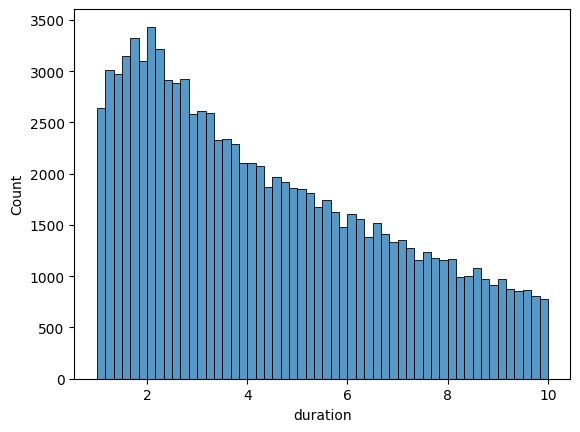

In [12]:
sns.histplot(df.duration)

In [13]:
speaker_counts = df.speaker_id.value_counts()
df = df[df.speaker_id.isin(speaker_counts[speaker_counts >= 10].index)]
df['speaker_idx'] = df.speaker_id.factorize()[0]

In [14]:
print(f"Number of speakers: {len(df.speaker_id.unique())}")

Number of speakers: 906


In [15]:
df_train, df_test = train_test_split(
    df, stratify=df.speaker_id, train_size=0.8, random_state=42
)
df_val, df_test = train_test_split(
    df_test, stratify=df_test.speaker_id, test_size=0.5, random_state=42
)

In [16]:
df_train.to_csv("libritts-train.csv", sep="|", quoting=csv.QUOTE_NONE, index=False)
df_val.to_csv("libritts-val.csv", sep="|", quoting=csv.QUOTE_NONE, index=False)
df_test.to_csv("libritts-test.csv", sep="|", quoting=csv.QUOTE_NONE, index=False)